In [64]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('../data/daily-minimum-temperatures-in-me.csv')

In [65]:
plt.style.use({'figure.figsize':(25,20)})
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [66]:
df.head()

,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


In [67]:
df.columns

Index(['Date', 'Temp'], dtype='str')

In [68]:
df['Date']=pd.to_datetime(df['Date'])
df=df.set_index('Date')

In [69]:
df.columns=['Temp']

In [70]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 3650 entries, 1981-01-01 to 1990-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Temp    3650 non-null   str  
dtypes: str(1)
memory usage: 57.0 KB


In [71]:
df.shape

(3650, 1)

In [72]:
df.describe()

,Temp
count,3650
unique,230
top,11.0
freq,51


In [38]:
df.head()

,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


In [73]:
print(df['Temp'].dtype)

str


In [74]:
df['Temp']=pd.to_numeric(df['Temp'],errors='coerce')

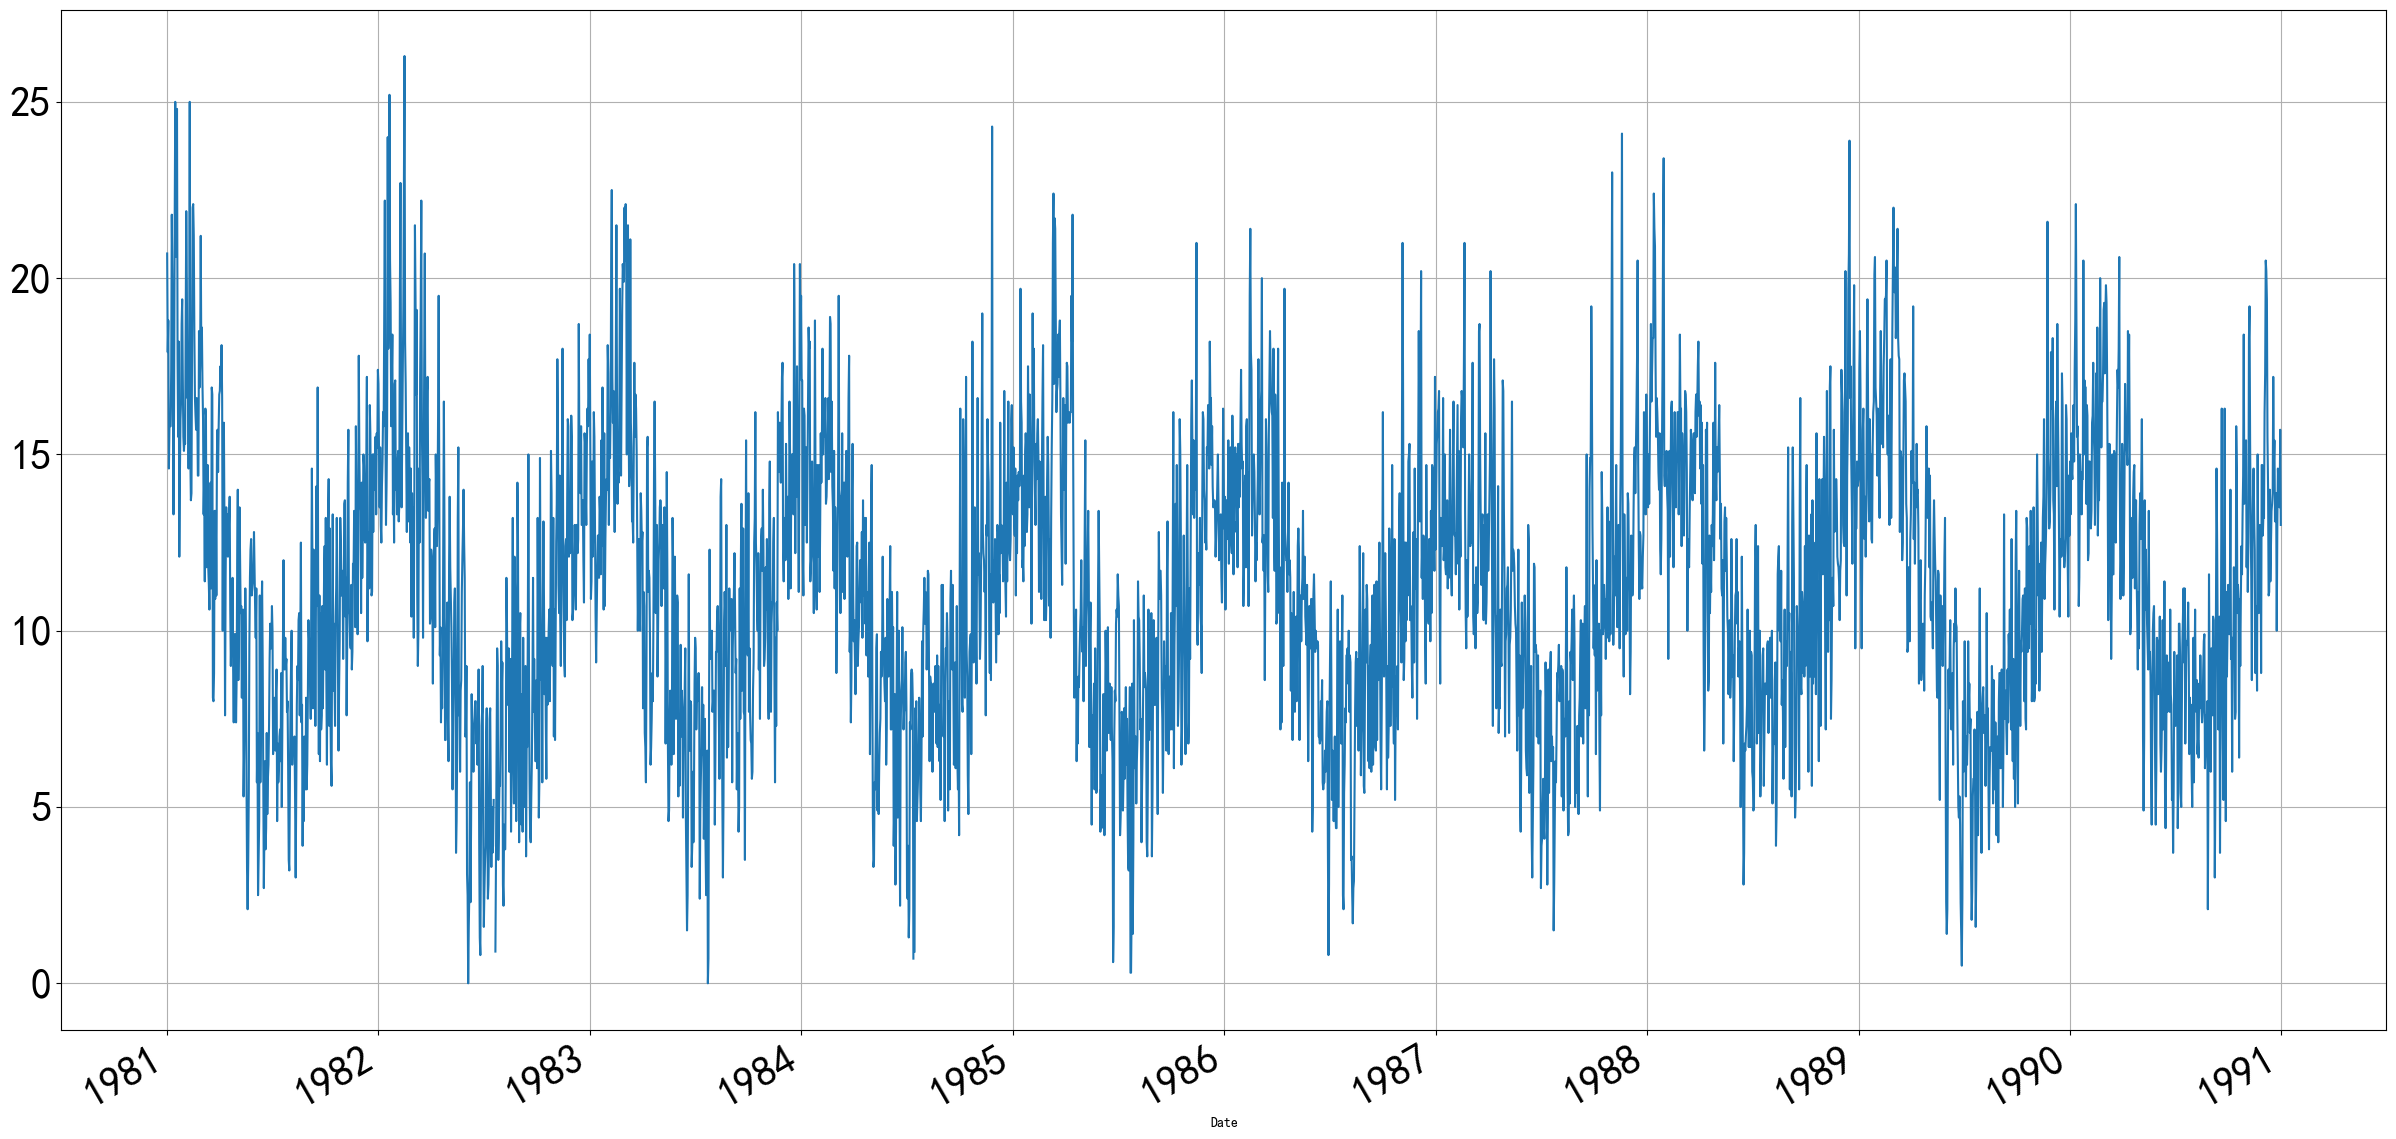

In [75]:
df['Temp'].plot(figsize=(30,15))
plt.tick_params(labelsize=30)
plt.grid()

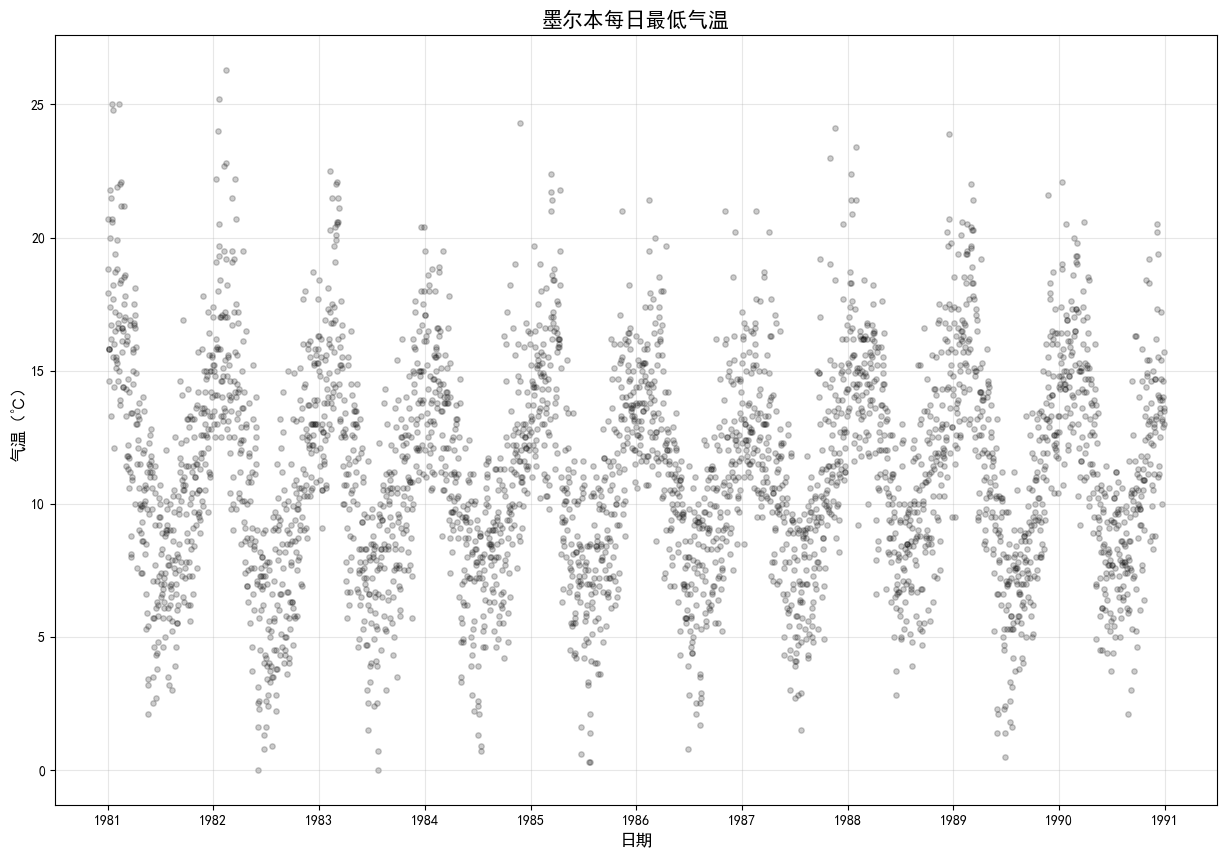

In [68]:
#todo设置画布的大小
plt.figure(figsize=(15,10))
#todo绘制散点图
plt.scatter(
    df.index,
    df['Temp'],
    color='black',
    alpha=0.2,
    s=15,
)
#todo设置标题，x轴标签，y轴标签，刻度字体大小，网格透明度
plt.title('墨尔本每日最低气温',fontsize=15)
plt.xlabel('日期',fontsize=12)
plt.ylabel('气温（℃）',fontsize=12)
plt.tick_params(labelsize=10)
plt.grid(alpha=0.3)
plt.show()

In [76]:
df['year']=df.index.year
df['month']=df.index.month
df['dow']=df.index.dayofweek
df['dom']=df.index.day

In [77]:
df.head()

,Temp,year,month,dow,dom
Date,,,,,
1981-01-01,20.7,1981,1,3,1
1981-01-02,17.9,1981,1,4,2
1981-01-03,18.8,1981,1,5,3
1981-01-04,14.6,1981,1,6,4
1981-01-05,15.8,1981,1,0,5


In [78]:
# 1. 先拿到星期几（0=周一，6=周日）
dow = df.index.dayofweek

# 2. 构造3列
df['is_weekend'] = dow >= 5  # 周六、周日 → True
df['is_saturday'] = dow == 5
df['is_sunday'] = dow == 6

In [79]:
df.head()

,Temp,year,month,dow,dom,is_weekend,is_saturday,is_sunday
Date,,,,,,,,
1981-01-01,20.7,1981,1,3,1,False,False,False
1981-01-02,17.9,1981,1,4,2,False,False,False
1981-01-03,18.8,1981,1,5,3,True,True,False
1981-01-04,14.6,1981,1,6,4,True,False,True
1981-01-05,15.8,1981,1,0,5,False,False,False


In [80]:
# ===================== 日期特征 =====================
day = df.index.day
dow = df.index.dayofweek

# 1. 上半月 / 下半月
df['half_month'] = (day > 15).astype(int) + 1

# 2. 上旬、中旬、下旬
df['three_part_month'] = pd.cut(
    day,
    bins=[0, 10, 20, 31],
    labels=[1, 2, 3],
    include_lowest=True
).astype(int)

# 3. 当月第几周（安全写法，所有版本都能用）
# 计算当前日期是当月的第几周
df['four_week_month'] = (day - 1) // 7 + 1

In [81]:
df.head()

,Temp,year,month,dow,dom,is_weekend,is_saturday,is_sunday,half_month,three_part_month,four_week_month
Date,,,,,,,,,,,
1981-01-01,20.7,1981,1,3,1,False,False,False,1,1,1
1981-01-02,17.9,1981,1,4,2,False,False,False,1,1,1
1981-01-03,18.8,1981,1,5,3,True,True,False,1,1,1
1981-01-04,14.6,1981,1,6,4,True,False,True,1,1,1
1981-01-05,15.8,1981,1,0,5,False,False,False,1,1,1


进行独热向量编码

In [82]:
columns_to_encoding = ['year', 'month', 'dow', 'dom', 'three_part_month', 'four_week_month']
dummy_df = pd.get_dummies(df,columns=columns_to_encoding)
dummy_df.head()

,Temp,is_weekend,is_saturday,is_sunday,half_month,year_1981,year_1982,year_1983,year_1984,year_1985,...,dom_30,dom_31,three_part_month_1,three_part_month_2,three_part_month_3,four_week_month_1,four_week_month_2,four_week_month_3,four_week_month_4,four_week_month_5
Date,,,,,,,,,,,,,,,,,,,,,
1981-01-01,20.7,False,False,False,1,True,False,False,False,False,...,False,False,True,False,False,True,False,False,False,False
1981-01-02,17.9,False,False,False,1,True,False,False,False,False,...,False,False,True,False,False,True,False,False,False,False
1981-01-03,18.8,True,True,False,1,True,False,False,False,False,...,False,False,True,False,False,True,False,False,False,False
1981-01-04,14.6,True,False,True,1,True,False,False,False,False,...,False,False,True,False,False,True,False,False,False,False
1981-01-05,15.8,False,False,False,1,True,False,False,False,False,...,False,False,True,False,False,True,False,False,False,False


In [83]:
dummy_df.columns

Index(['Temp', 'is_weekend', 'is_saturday', 'is_sunday', 'half_month',
       'year_1981', 'year_1982', 'year_1983', 'year_1984', 'year_1985',
       'year_1986', 'year_1987', 'year_1988', 'year_1989', 'year_1990',
       'month_1', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6',
       'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12',
       'dow_0', 'dow_1', 'dow_2', 'dow_3', 'dow_4', 'dow_5', 'dow_6', 'dom_1',
       'dom_2', 'dom_3', 'dom_4', 'dom_5', 'dom_6', 'dom_7', 'dom_8', 'dom_9',
       'dom_10', 'dom_11', 'dom_12', 'dom_13', 'dom_14', 'dom_15', 'dom_16',
       'dom_17', 'dom_18', 'dom_19', 'dom_20', 'dom_21', 'dom_22', 'dom_23',
       'dom_24', 'dom_25', 'dom_26', 'dom_27', 'dom_28', 'dom_29', 'dom_30',
       'dom_31', 'three_part_month_1', 'three_part_month_2',
       'three_part_month_3', 'four_week_month_1', 'four_week_month_2',
       'four_week_month_3', 'four_week_month_4', 'four_week_month_5'],
      dtype='str')

In [98]:
dummy_df.shape

(3650, 73)

In [103]:
# 删除目标变量中的空值（不管列名叫什么，自动删空行）
df = df.dropna()

# 再检查还有没有空值（输出应该是 0）
print("空值数量：", df.isnull().sum().sum())

空值数量： 0


In [106]:
dummy_df=dummy_df.dropna()
print("空值数量：", df.isnull().sum().sum())

空值数量： 0


In [107]:
from sklearn.model_selection import train_test_split
x_dummy=dummy_df.drop('Temp',axis=1)
y=dummy_df['Temp']
x_train,x_test,y_train,y_test=train_test_split(x_dummy,y,test_size=0.2,random_state=42)


In [111]:
from sklearn import linear_model
lr_reg = linear_model.LinearRegression()
lr_reg.fit(x_train,y_train)
y_test_pred = lr_reg.predict(x_test)
print('截距',lr_reg.intercept_)
print('系数',lr_reg.coef_)

截距 11.482487231168683
系数 [-0.07509948 -0.02863579 -0.04646369 -0.13346009  0.26457431 -0.41031143
 -0.00697817 -0.59101276  0.08299861 -0.39277481 -0.38443552  0.7930739
  0.10349597  0.54136991  3.83172372  4.05414093  3.35058408  0.79447017
 -1.12350803 -4.0008479  -4.27287109 -3.26156754 -2.22620981 -0.96344996
  1.23439652  2.58313891 -0.10525393  0.05024005  0.17102932 -0.1410915
  0.10017553 -0.02863579 -0.04646369  0.30516981  0.17298553 -0.17596604
 -0.04758131 -0.27061347 -0.0282765   0.10995646  0.05772871  0.00557354
 -0.08816208 -0.07964175 -0.15812367 -0.17643448  0.28995369  0.21689163
 -0.0579048   0.04426011 -0.16831303  0.23229373 -0.1196664  -0.17563559
 -0.18008351  0.07966204  0.09880037 -0.05907206 -0.26916781 -0.15872106
  0.2764855  -0.04531083  0.20366436  0.16524889  0.04081466  0.02331503
 -0.0641297   0.06567449 -0.14910604 -0.02807435 -0.21209653  0.32360242]


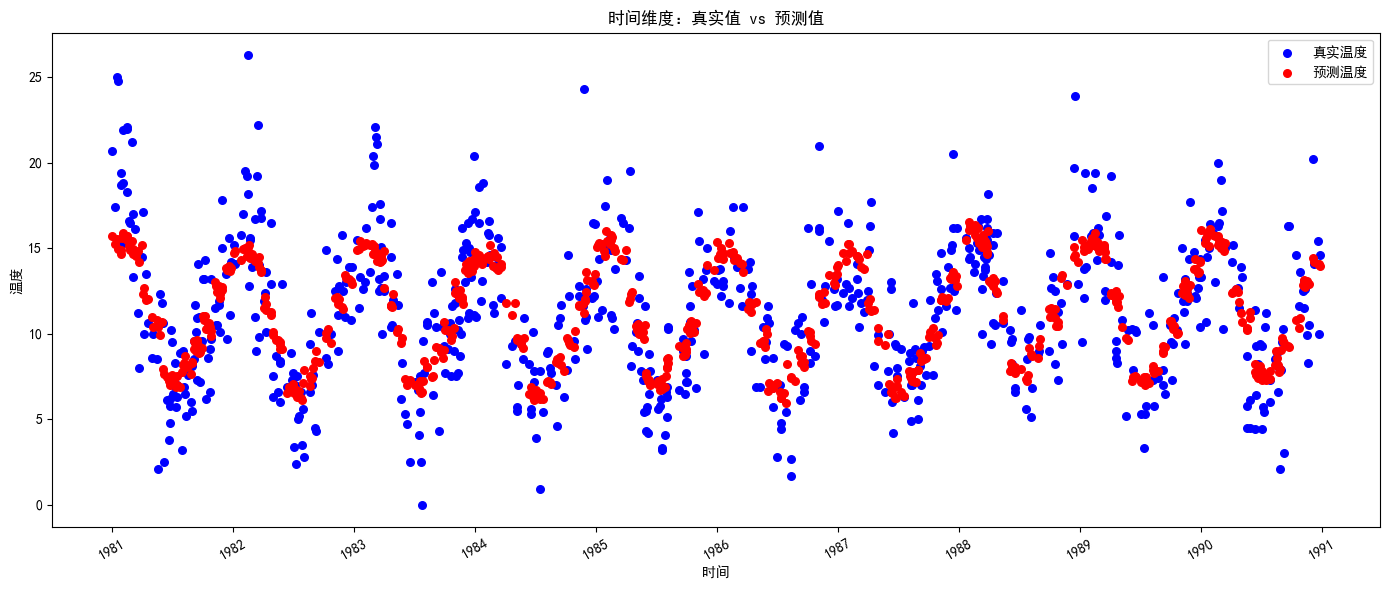

In [119]:
import matplotlib.pyplot as plt

# 最简单最稳：直接用 y_test 的索引当时间（就是日期！）
test_date = y_test.index

plt.figure(figsize=(14,6))

# 真实值：蓝色
plt.scatter(test_date, y_test, color='blue', label='真实温度', s=30)

# 预测值：红色
plt.scatter(test_date, y_test_pred, color='red', label='预测温度', s=30)

plt.xlabel('时间')
plt.ylabel('温度')
plt.title('时间维度：真实值 vs 预测值')
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [120]:
from sklearn.metrics import r2_score

# 计算测试集 R²
r2 = r2_score(y_test, y_test_pred)

print(f"模型 R² 分数：{r2:.4f}")

模型 R² 分数：0.5577


多项式回归

In [121]:
from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree=2)
x_poly = poly_reg.fit_transform(x_dummy)

In [122]:
x_poly.shape

(3647, 2701)

In [123]:
from sklearn import linear_model
lin_reg2 = linear_model.LinearRegression()
lin_reg2.fit(x_poly,y)
y_test_pred = lin_reg2.predict(poly_reg.fit_transform(x_test))

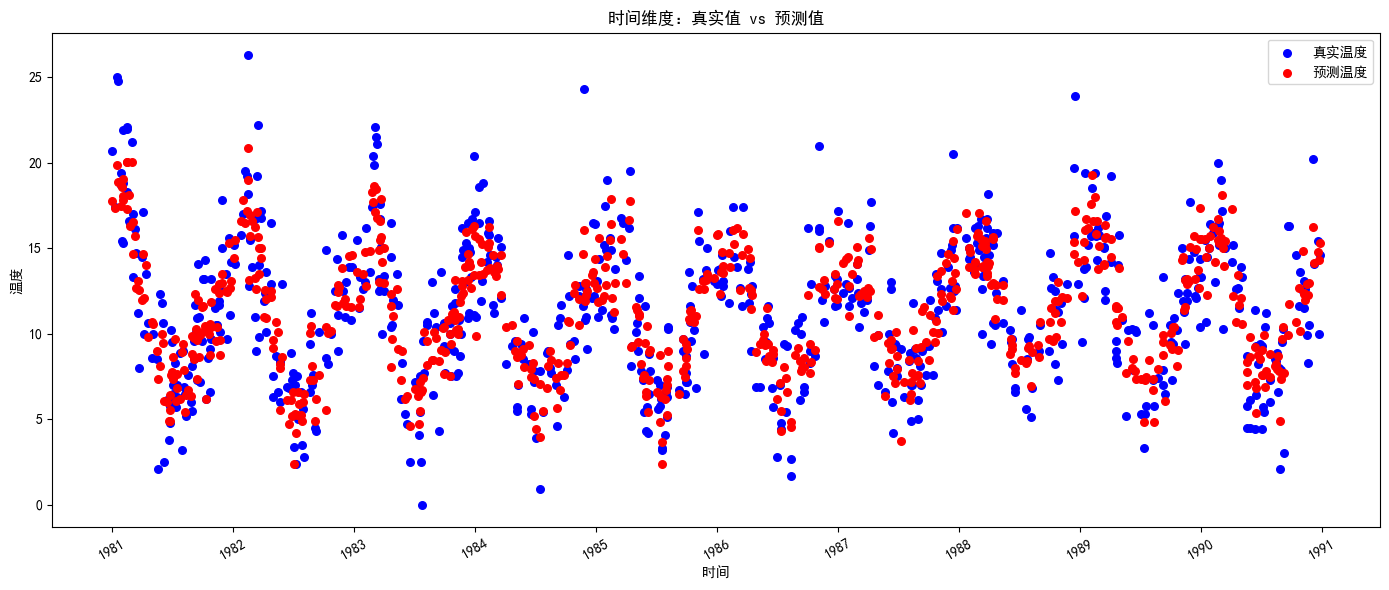

In [124]:
import matplotlib.pyplot as plt

# 最简单最稳：直接用 y_test 的索引当时间（就是日期！）
test_date = y_test.index

plt.figure(figsize=(14,6))

# 真实值：蓝色
plt.scatter(test_date, y_test, color='blue', label='真实温度', s=30)

# 预测值：红色
plt.scatter(test_date, y_test_pred, color='red', label='预测温度', s=30)

plt.xlabel('时间')
plt.ylabel('温度')
plt.title('时间维度：真实值 vs 预测值')
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [125]:
from sklearn.metrics import r2_score

# 计算测试集 R²
r2 = r2_score(y_test, y_test_pred)

print(f"模型 R² 分数：{r2:.4f}")

模型 R² 分数：0.7352


In [126]:
from sklearn.model_selection import train_test_split
x=df.drop('Temp',axis=1)
y=df['Temp']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [129]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
parameters = {
    'n_estimators': [5,10,20,50,100],
    'max_depth': [3,5,7],
    'max_features':[0.6,0.7,0.8,1]
}
rf = RandomForestRegressor()
grid = GridSearchCV(estimator=rf, param_grid=parameters, cv=3)
grid.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'max_features': [0.6, 0.7, ...], 'n_estimators': [5, 10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the scor

In [130]:
# 查看最优参数
print("最优参数：", grid.best_params_)

# 查看交叉验证的最优得分（默认是负MSE，你之前指定了scoring='r2'的话，这里就是R²）
print("交叉验证最优得分：", grid.best_score_)

最优参数： {'max_depth': 7, 'max_features': 0.8, 'n_estimators': 100}
交叉验证最优得分： 0.5620584171093254


In [131]:
rf_reg=grid.best_estimator_
y_test_pred = rf_reg.predict(x_test)

In [132]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

print("==== 随机森林模型评估 ====")
print("R² 分数：", r2_score(y_test, y_test_pred))       # 最重要！越接近1越好
print("RMSE：", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("MAE：", mean_absolute_error(y_test, y_test_pred))

==== 随机森林模型评估 ====
R² 分数： 0.5962574665270403
RMSE： 2.685843910469564
MAE： 2.0941310580245878
